In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import sklearn as sk
from utils.flux_integration import Integrating_Flux
from utils.phase_detection import Find_Proton_Flux_Phases
import torch as tc

[Data Source](https://omniweb.gsfc.nasa.gov/ftpbrowser/soho_ephin_flux_hr.html)

# 0.1 Testing W/ Lower Fidelity Proton Data

In [8]:
proton_flux_df = pd.read_csv('data/enviromental/ephin-soho/proton_flux_1995Dec-2002Jan_EPHINSOHO.lst', header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+") 
proton_flux_df

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Lewis\AppData\Local\Temp\ipykernel_16792\2513693952.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  proton_flux_df = pd.read_csv('data/enviromental/ephin-soho/proton_flux_1995Dec-2002Jan_EPHINSOHO.lst', header = None, names = ['Year', 'DOY', 'Hour', 'P4', 'P8', 'P25', 'P41'], sep = "\s+")


,Year,DOY,Hour,P4,P8,P25,P41
0,1995,342,0,0.000042,0.000020,0.000065,0.000049
1,1995,342,1,0.000028,0.000036,0.000069,0.000061
2,1995,342,2,0.000014,0.000027,0.000068,0.000073
3,1995,342,3,0.000041,0.000034,0.000069,0.000074
4,1995,342,4,0.000028,0.000027,0.000033,0.000062
...,...,...,...,...,...,...,...
53899,2002,30,19,0.114190,0.009482,0.000173,0.000050
53900,2002,30,20,0.109340,0.008745,0.000191,0.000054
53901,2002,30,21,0.108360,0.008860,0.000185,0.000046
53902,2002,30,22,0.108220,0.009084,0.000184,0.000053


# 0.2 Power Law Spectrum
**[Torres 2025](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024SW003921)**: The 
10 MeV proton intensity is calculated from the differential fluxes in four energy (P4, P8, P25, and P41) channels through an integration over the energy. The P8 proton channel covers an energy range of 7.8–25 MeV, P25 covers 25–40.9 MeV, P41 covers 40.9–53 MeV, while the P4 channel covers 4.3–7.8 MeV. We assume that particles above the P41 channel coverage make little contribution to the integral flux of MeV protons. The integral flux is calculated by summing energy-integrated fluxes in the last three (P8, P25, and P41) channels minus the amount between 7.8 and 10 MeV, which is determined by the integration of a power-law spectrum interpolated using the differential fluxes in the first two channels (P4 and P8) and their mean energies. We use the first two channels to do the interpolation because their fluxes have relatively low error bars due to high count rates in low-energy channels.

Too find channel between 7.8- 10 MeV we fall the Power Law Scale and make use of its invariance:

$\Phi_n = \alpha \nu_n^\beta$ (1)

Using the channels P4 and P8:

$\Phi_4 = \alpha \nu_4^\beta$ (2) 

$\Phi_8 = \alpha \nu_8^\beta$ (3)

Converting frequency to energy: $\nu_n = \frac{\bar{E}_n}{h}$ (4), $h = 4.136 \times 10^{-21} \text{Mev/s}$

Rewriting (2): $\alpha = \frac{\Phi_4}{\nu_4^\beta}$

And then plugging into (3): $\Phi_8 = \Phi_4 \left(\frac{\nu_8}{\nu_4} \right)^\beta$ (5)

Solving for $\beta$: $\beta = \frac{\log [\Phi_8 / \Phi_4]}{\log [\nu_8 / \nu_4]}$

Solving for $\alpha$: $\alpha = \frac{\Phi_4}{\nu_4^\beta}$ With newly discovered $\beta$

Now we can solve the flux over any range we want using our new parameters $\alpha, \beta$: $\Phi_x = \alpha \nu_x^\beta$




In [9]:
proton_flux_df = Integrating_Flux(proton_flux_df)

c:\Users\Lewis\Documents\SWLG_Code\code\utils\flux_integration.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.log(a_p8_flux / a_p4_flux) / np.log(a_p8_avg_E / a_p4_avg_E)
c:\Users\Lewis\Documents\SWLG_Code\code\utils\flux_integration.py:40: RuntimeWarning: invalid value encountered in scalar subtract
  integral = alpha * (a_E2**(beta+1) - a_E1**(beta+1)) / (beta + 1)
c:\Users\Lewis\Documents\SWLG_Code\code\utils\flux_integration.py:34: RuntimeWarning: invalid value encountered in scalar divide
  beta = np.log(a_p8_flux / a_p4_flux) / np.log(a_p8_avg_E / a_p4_avg_E)
c:\Users\Lewis\Documents\SWLG_Code\code\utils\flux_integration.py:34: RuntimeWarning: divide by zero encountered in log
  beta = np.log(a_p8_flux / a_p4_flux) / np.log(a_p8_avg_E / a_p4_avg_E)
c:\Users\Lewis\Documents\SWLG_Code\code\utils\flux_integration.py:35: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = a_p4_flux / (a_p4_avg_E ** beta)
c:\Users\Lewis\Documents\SWLG_

# 0.3 Finding Onset, Peaks, and Ends
No specific technique was explained rather the "program" will sort it. heres my attempt and i will compare with theirs

In [10]:
Find_Proton_Flux_Phases(proton_flux_df, 40, "phases_11061997_11032002")

,Onset Timestamp,Onset Flux,Threshold Timestamp,Threshold Flux,Peak Timestamp,Peak Flux,End Timestamp,End Flux,Storm Duration
0,1997-11-04 06:00:00,0.066021,1997-11-04 08:00:00,16.453934,1997-11-04 09:00:00,65.405438,1997-11-05 20:00:00,1.968064,1 days 14:00:00
1,1997-11-06 12:00:00,0.852781,1997-11-06 15:00:00,15.473794,1997-11-07 00:00:00,265.177378,1997-11-09 21:00:00,1.973644,3 days 09:00:00
2,1998-04-20 11:00:00,0.026764,1998-04-20 15:00:00,10.108851,1998-04-21 10:00:00,541.485781,1998-04-25 11:00:00,1.911519,5 days 00:00:00
4,1998-05-02 14:00:00,0.142543,1998-05-02 16:00:00,17.901954,1998-05-02 19:00:00,22.527648,1998-05-04 03:00:00,1.698666,1 days 13:00:00
5,1998-05-06 07:00:00,0.196682,1998-05-06 09:00:00,200.275670,1998-05-06 09:00:00,200.275670,1998-05-07 06:00:00,1.843606,0 days 23:00:00
6,1998-11-14 05:00:00,0.007492,1998-11-14 08:00:00,15.649854,1998-11-14 13:00:00,119.723238,1998-11-21 16:00:00,0.012630,7 days 11:00:00
7,1999-04-24 14:00:00,0.014742,1999-04-24 20:00:00,11.409315,1999-04-25 01:00:00,17.585362,1999-04-25 22:00:00,1.970650,1 days 08:00:00
8,1999-06-01 21:00:00,0.528786,1999-06-02 04:00:00,14.207384,1999-06-02 06:00:00,40.824945,1999-06-04 05:00:00,1.994649,2 days 08:00:00
9,1999-06-04 07:00:00,1.681259,1999-06-04 09:00:00,15.806102,1999-06-04 11:00:00,42.120864,1999-06-06 06:00:00,1.944769,1 days 23:00:00
10,2000-02-18 10:00:00,0.542037,2000-02-18 12:00:00,12.002118,2000-02-18 12:00:00,12.002118,2000-02-18 20:00:00,1.810801,0 days 10:00:00


# 0.4 Visualization

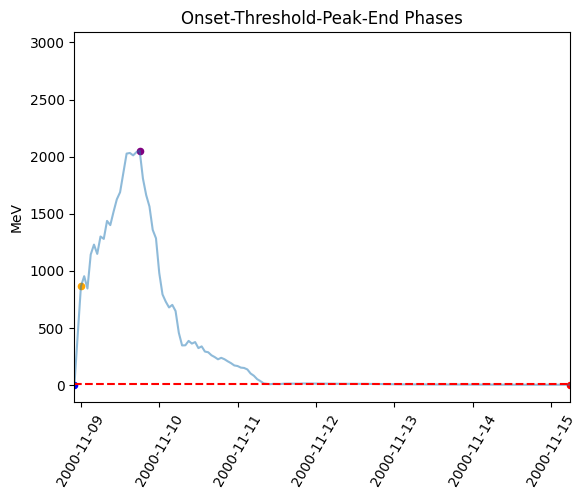

In [11]:
phase_data_df = Find_Proton_Flux_Phases(proton_flux_df, 100, "phases_11061997_11032002")

plt.title("Onset-Threshold-Peak-End Phases")
plt.ylabel("MeV")
plt.style.use("default")
plt.plot(proton_flux_df["Timestamp"], proton_flux_df["P_tot"], alpha = .5)


plt.scatter(phase_data_df["Onset Timestamp"], phase_data_df["Onset Flux"], c = "blue", s = 20 )


plt.scatter(phase_data_df["Threshold Timestamp"], phase_data_df["Threshold Flux"], c ="orange", s = 20 )

plt.scatter(phase_data_df["End Timestamp"], phase_data_df["End Flux"], c ="red", s = 20 )

plt.scatter(phase_data_df["Peak Timestamp"], phase_data_df["Peak Flux"], c = "purple", s = 20)

plt.xticks(rotation = 60)

plt.axhline(y=10, color='r', linestyle='--')
plt.xlim(
    pd.Timestamp("2000-11-08 22:00:00	"),
    pd.Timestamp("2000-11-15 06:00:00	")
)
plt.show()

# 1. Replicating Torres 2025 with Transformer M1

To form a baseline, we apply a single neural network model to the whole data set; this approach will be referred to as M1 (One Model for intensity prediction). We compare the multilayer perceptron algorithm (which from here on will be denoted as NN, or neural network) to recurrent neural networks (RNNs); RNN are designed to work with time-series data, so they are expected to perform better in this study. The Keras implementation in Python is used to create our models, with the Gated Recurrent Units (GRU) layer for the RNN model. GRU layers are described in more detail by Chung et al. (2014). Both the NN and RNN models consist of two layers: a hidden layer with 30 units, and an dense output layer with one unit. The hidden layer for the NN model is a dense layer, while the hidden layer for the RNN model is a GRU layer. During training, the neural network minimizes the loss function, which is the mean square error (MSE) between the target proton intensity and the predicted proton intensity. Similarly to the inputs, the outputs are also in the natural logarithm space, so MSE is computed in the natural logarithm space.

## 1.1 Getting Data
Gathering and mergeing all electron and proton data into one file with the same candence to easily read in our transformer model

Proton Flux Data:

Electron Flux Data:

In [12]:
from utils.merge_proton_electron import Merge_Proton_Electron
proton_path = "data/enviromental/ephin-soho/5min_proton_1997-2025/5min/"
Merge_Proton_Electron(
    proton_path="proton_path",
    e150_path="data/enviromental/ephin-soho/electron/E150_1997_2025.csv",
    e300_path="data/enviromental/ephin-soho/electron/E300_1997_2017.csv",
    output_path="data/enviromental/ephin-soho/merged"
)

Loading E150...
Loading E300...
Skipping 1997 — file not found
Skipping 1998 — file not found
Skipping 1999 — file not found
Skipping 2000 — file not found
Skipping 2001 — file not found
Skipping 2002 — file not found
Skipping 2003 — file not found
Skipping 2004 — file not found
Skipping 2005 — file not found
Skipping 2006 — file not found
Skipping 2007 — file not found
Skipping 2008 — file not found
Skipping 2009 — file not found
Skipping 2010 — file not found
Skipping 2011 — file not found
Skipping 2012 — file not found
Skipping 2013 — file not found
Skipping 2014 — file not found
Skipping 2015 — file not found
Skipping 2016 — file not found
Skipping 2017 — file not found
Skipping 2018 — file not found
Skipping 2019 — file not found
Skipping 2020 — file not found
Skipping 2021 — file not found
Skipping 2022 — file not found
Skipping 2023 — file not found
Skipping 2024 — file not found
Skipping 2025 — file not found
Done.


### 1.1.1 Filter Only Torres Relevant Years and Phases

Note on usable data: since each instance requires 2 hr of data before it and either 30 min or 1 hr after, the first 24. In each of the three approaches, the features used are the >0.25 MeV electron intensities, >0.67 MeV electron intensities, and >10 MeV proton intensities, and all are tested with and without phase inputs, with both NN and RNN algorithms.

In [26]:

torres_electron_proton_merged_df = pd.DataFrame([])

for i in range(1997, 2003, 1):
    merged_year_df = pd.read_csv('data/enviromental/ephin-soho/merged/merged_' + str(i) + '.csv')
    torres_electron_proton_merged_df = pd.concat([torres_electron_proton_merged_df, merged_year_df], ignore_index= True)

torres_merged_phases = Find_Proton_Flux_Phases(torres_electron_proton_merged_df, 50, "torres_merged_phases")


for col in ["E150", "E300", "P_tot"]:
    torres_electron_proton_merged_df[col] = np.log(
        np.clip(torres_electron_proton_merged_df[col], 1e-6, None)
    )

torres_electron_proton_merged_df["Timestamp"] = pd.to_datetime(torres_electron_proton_merged_df["Timestamp"])

torres_merged_phases

,Onset Timestamp,Onset Flux,Threshold Timestamp,Threshold Flux,Peak Timestamp,Peak Flux,End Timestamp,End Flux,Storm Duration
0,1997-11-04 07:10:00,0.763935,1997-11-04 08:10:00,11.138004,1997-11-04 10:10:00,90.694208,1997-11-05 19:35:00,1.988175,1 days 12:25:00
4,1997-11-06 13:50:00,0.658699,1997-11-06 14:40:00,14.967772,1997-11-06 15:05:00,16.857679,1997-11-09 20:20:00,1.960739,3 days 06:30:00
17,1998-04-20 12:15:00,0.244661,1998-04-20 15:30:00,10.025049,1998-04-20 18:55:00,53.428215,1998-04-25 10:45:00,1.944376,4 days 22:30:00
35,1998-05-02 14:10:00,0.052890,1998-05-02 16:15:00,17.604268,1998-05-02 16:20:00,35.439869,1998-05-04 02:50:00,0.662789,1 days 12:40:00
39,1998-05-06 08:10:00,0.083795,1998-05-06 08:50:00,32.822333,1998-05-06 10:15:00,280.478874,1998-05-07 05:10:00,1.939265,0 days 21:00:00
41,1998-11-14 06:55:00,1.185575,1998-11-14 07:35:00,10.722243,1998-11-14 08:25:00,25.091082,1998-11-21 16:15:00,0.010487,7 days 09:20:00
46,1999-05-27 12:10:00,1.387753,1999-05-27 13:25:00,10.321638,1999-05-27 13:25:00,10.321638,1999-05-27 18:05:00,1.931123,0 days 05:55:00
47,1999-06-01 23:00:00,1.351497,1999-06-02 04:40:00,17.644507,1999-06-02 08:25:00,56.848501,1999-06-04 04:10:00,1.903449,2 days 05:10:00
53,1999-06-04 08:25:00,1.480874,1999-06-04 09:15:00,10.934380,1999-06-04 11:15:00,49.847410,1999-06-06 04:25:00,1.966035,1 days 20:00:00
57,2000-02-18 10:55:00,1.343492,2000-02-18 11:30:00,12.055144,2000-02-18 11:45:00,18.564151,2000-02-18 19:45:00,1.853987,0 days 08:50:00


## 1.2 Preparing Our Data For Transformer

## Define Statements

In [14]:
import yaml

with open("utils/config.yaml") as f:
    config = yaml.safe_load(f)


n_encoder_layers = config["model"]["n_encoder_layers"]
dim_value        = config["model"]["dim_value"]
n_heads          = config["model"]["n_heads"]
dropout          = config["model"]["dropout"]
train_new_model  = config["model"]["train_new_model"]
model_name_use   = config["model"]["model_name_use"]

lr             = config["training"]["lr"]
n_epochs       = config["training"]["n_epochs"]
batch_size     = config["training"]["batch_size"]
electron_range = config["training"]["electron_range"]
window_size    = config["training"]["electron_range"]
num_workers    = config["training"]["num_workers"]

future_proton_out = config["data"]["future_proton_out"]
train_split       = config["data"]["train_split"]

In [15]:
from torch.utils.data import Dataset, DataLoader

class ParticleFluxDatasetM1(Dataset):

    def __init__(self, a_particle_flux_df, a_electron_range, a_proton_instance_after):
        self.e150 = a_particle_flux_df["E150"].values
        self.e300 = a_particle_flux_df["E300"].values
        self.p_tot = a_particle_flux_df["P_tot"].values
        self.electron_range = a_electron_range
        self.proton_instance_after = a_proton_instance_after

    def __len__(self):
        return self.p_tot.shape[0] - self.electron_range - self.proton_instance_after

    def __getitem__(self, idx):
        e150 = self.e150[idx : idx + self.electron_range]
        e300 = self.e300[idx : idx + self.electron_range]
        p_y  = self.p_tot[idx: idx + self.electron_range]
        
        x = tc.tensor(np.column_stack([e150, e300, p_y]), dtype=tc.float32)
        y = tc.tensor(self.p_tot[idx + self.electron_range + self.proton_instance_after], dtype=tc.float32)

        sample = {"Current_Flux_Data": x,
                  "Target_Proton_Data": y}

        return sample

In [16]:
split_idx = int(len(torres_electron_proton_merged_df) * train_split)

train_df = torres_electron_proton_merged_df.iloc[:split_idx].reset_index(drop=True)
test_df = torres_electron_proton_merged_df.iloc[split_idx:].reset_index(drop=True)

e150_mean, e150_std = train_df["E150"].mean(), train_df["E150"].std()
e300_mean, e300_std = train_df["E300"].mean(), train_df["E300"].std()
p_tot_mean, p_tot_std = train_df["P_tot"].mean(), train_df["P_tot"].std()



for df in [train_df, test_df]:
    df["E150"] = (df["E150"] - e150_mean) / e150_std
    df["E300"] = (df["E300"] - e300_mean) / e300_std
    df["P_tot"] = (df["P_tot"] - p_tot_mean) / p_tot_std


train_dataset = ParticleFluxDatasetM1(train_df,electron_range, future_proton_out)
test_dataset = ParticleFluxDatasetM1(test_df, electron_range, future_proton_out)

train_loader = DataLoader(train_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

particle_flux_dataset_m1 = ParticleFluxDatasetM1(train_df, electron_range, future_proton_out)
m1_dataloader = DataLoader(particle_flux_dataset_m1, batch_size=batch_size, num_workers=num_workers)   


## 1.3 Building Transformer

https://towardsdatascience.com/how-to-make-a-pytorch-transformer-for-time-series-forecasting-69e073d4061e/

In [17]:
import torch
import torch.nn as nn


class SEPTransformerM1(nn.Module):
    def __init__(self, input_size=3, dim_val=dim_value, n_heads=n_heads, 
                 n_encoder_layers=n_encoder_layers, dropout=dropout, window_size=window_size):
        super().__init__()
        
     
        self.input_layer = nn.Linear(input_size, dim_val)
        
     
        self.pos_encoding = nn.Parameter(torch.zeros(1, window_size, dim_val))
   
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim_val,
            nhead=n_heads,
            dim_feedforward=dim_val * 4,
            dropout=dropout,
            batch_first=True
        )
        
      
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_encoder_layers)
        
        
        self.output_layer = nn.Linear(dim_val, 1)
    
    def forward(self, x):
        
        x = self.input_layer(x)       
        x = x + self.pos_encoding      
        x = self.encoder(x)           
        x = x[:, -1, :]                
        x = self.output_layer(x)       
        return x

# 1.4 Training Model on Test Data

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MSE = nn.MSELoss()
model_name = "M1_" + str(n_encoder_layers) + "enc_" + str(lr) + "lr_" + str(n_epochs) + "epoch_" + proton_path[-5:-1]

if train_new_model:
    print(f"Using {device}")
    model = SEPTransformerM1(input_size=3, dim_val=dim_value, window_size=window_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    n_batches = len(m1_dataloader)

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0

        for batch_counter, batch in enumerate(m1_dataloader, start=1):
            x = batch["Current_Flux_Data"].to(device)
            y = batch["Target_Proton_Data"].to(device)

            pred = model(x).squeeze()
            loss = MSE(pred, y)
            
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            batch_per = 100 * batch_counter / n_batches
            print(f"\rEpoch {epoch+1}/{n_epochs} | batch {batch_counter}/{n_batches} "
                  f"({batch_per:.1f}%) | running loss {total_loss/batch_counter:.4f}",
                  end="", flush=True)


        avg_loss = total_loss / n_batches
        print(f"\rEpoch {epoch+1}/{n_epochs} complete — Avg Loss: {avg_loss:.4f}" + " " * 30)

    print(f"saving {model_name}...")
    torch.save(model.state_dict(), 'models/' + model_name_use)
    model_name_use = model_name
    print("Done.")

# 1.5 Testing M1 Transformer Model 

# 1.5.1 Whole Test Set

In [19]:
import matplotlib.dates as mdates

model = SEPTransformerM1(input_size=3, dim_val=64, window_size=window_size).to(device)

offset = window_size + future_proton_out
model.load_state_dict(tc.load("models/" + model_name))
model.eval()
test_loss = 0
predictions  = tc.tensor([]).to(device)
original     = tc.tensor([]).to(device)
losses = tc.tensor([]).to(device)
with torch.no_grad():
    for batch in test_loader:
        x = batch["Current_Flux_Data"].to(device)
        y = batch["Target_Proton_Data"].to(device)

        pred = model(x).squeeze()
        original    = tc.cat((original, y.flatten()))
        predictions = tc.cat((predictions, pred.flatten()))

        loss = MSE(y, pred)
        losses = tc.cat((losses, loss.flatten()))
        test_loss += loss.item()

pred_log = predictions.detach().cpu().numpy() * p_tot_std + p_tot_mean
orig_log = original.detach().cpu().numpy() * p_tot_std + p_tot_mean

test_aligned_df = test_df.iloc[offset : offset + len(predictions)].copy()
test_aligned_df["predicted"] = pred_log
test_aligned_df["original"] = orig_log

# 1.5.1.1 Comparing To Baseline

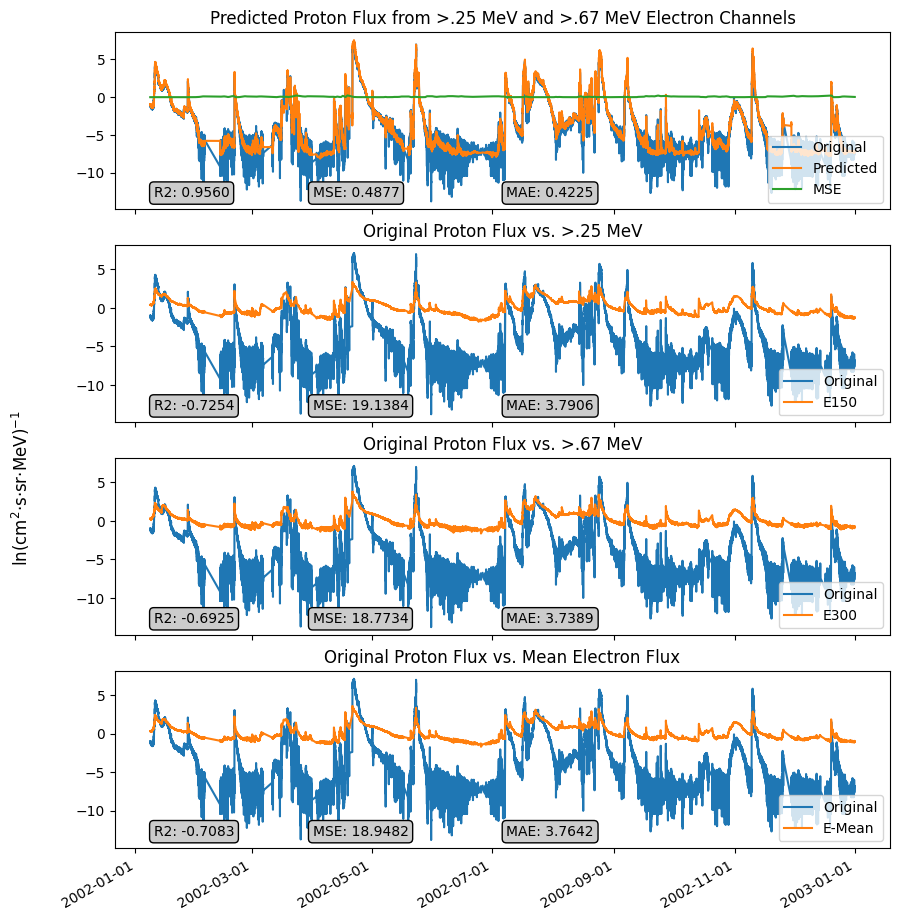

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12))
fig.autofmt_xdate()
fig.supylabel(r"$\ln( \text{cm}^2·\text{s}·\text{sr}·\text{MeV})^{-1}$")

# MAE timestamps for the first subplot
x = np.linspace(0, test_aligned_df.shape[0], test_aligned_df.shape[0] // batch_size + 1).round().astype(int)
x[-1] = x[-1] - 1
MSE_timestamps = test_aligned_df["Timestamp"].iloc[x]

# Mean electron flux for the last subplot
mean_electron_flux = (test_aligned_df["E300"] + test_aligned_df["E150"]) / 2

# Configuration for each subplot: (comparison series, label, title)
panels = [
    (test_aligned_df["predicted"], "Predicted", "Predicted Proton Flux from >.25 MeV and >.67 MeV Electron Channels"),
    (test_aligned_df["E150"],      "E150",      "Original Proton Flux vs. >.25 MeV"),
    (test_aligned_df["E300"],      "E300",      "Original Proton Flux vs. >.67 MeV"),
    (mean_electron_flux,           "E-Mean",    "Original Proton Flux vs. Mean Electron Flux"),
]

for ax, (series, label, title) in zip(axes, panels):
    r2  = sk.metrics.r2_score(test_aligned_df["original"], series)
    mse = sk.metrics.mean_squared_error(test_aligned_df["original"], series)
    mae = sk.metrics.mean_absolute_error(test_aligned_df['original'], series)


    ax.plot(test_aligned_df["Timestamp"], test_aligned_df["original"], label="Original", zorder=1)
    ax.plot(test_aligned_df["Timestamp"], series, label=label, zorder=2)

    ax.set_title(title)
    ax.annotate(f'R2: {r2:.4f}', xy=(0.001, 0.001), xytext=(0.05, 0.07),
                xycoords='axes fraction', bbox=dict(boxstyle="round", fc="0.8"))
    ax.annotate(f'MSE: {mse:.4f}', xy=(0.001, 0.001), xytext=(0.255, 0.07),
                xycoords='axes fraction', bbox=dict(boxstyle="round", fc="0.8"))
    ax.annotate(f'MAE: {mae:.4f}', xy=(0.001, 0.001), xytext=(0.505, 0.07),
            xycoords='axes fraction', bbox=dict(boxstyle="round", fc="0.8"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.legend(loc='lower right')

axes[0].plot(MSE_timestamps, losses.detach().cpu().numpy(), label="MSE")
axes[0].legend(loc='lower right')  

plt.show()

# 1.5.2 Rising Only (Onset to Peak)

In [ ]:
from utils.slice_rising import Slice_Rising

rising_df = Slice_Rising(test_aligned_df, torres_merged_phases)

mae = sk.metrics.mean_absolute_error(rising_df['original'], rising_df['predicted'])
print(f"Rising-phase MAE: {mae}")

persistence_pred = rising_df['original'].shift(future_proton_out)
valid = persistence_pred.notna()

mae_model = sk.metrics.mean_absolute_error(rising_df['original'][valid], rising_df['predicted'][valid])
mae_persist = sk.metrics.mean_absolute_error(rising_df['original'][valid], persistence_pred[valid])

print(f"Model rising-phase MAE:       {mae_model:.4f}")
print(f"Persistence rising-phase MAE: {mae_persist:.4f}")

Rising-phase MAE: 0.3446537577977093
Model rising-phase MAE:       0.3435
Persistence rising-phase MAE: 0.4695
              Timestamp  Year  Month  Day  Hour  Minute  DOY       P4  \
0   2002-01-10 18:00:00  2002      1   10    18       0   10   1.7276   
1   2002-01-10 18:05:00  2002      1   10    18       5   10   1.6113   
2   2002-01-10 18:10:00  2002      1   10    18      10   10   1.6169   
3   2002-01-10 18:15:00  2002      1   10    18      15   10   1.7348   
4   2002-01-10 18:20:00  2002      1   10    18      20   10   1.7160   
..                  ...   ...    ...  ...   ...     ...  ...      ...   
501 2002-08-24 08:35:00  2002      8   24     8      35  236  30.4360   
502 2002-08-24 08:40:00  2002      8   24     8      40  236  31.4750   
503 2002-08-24 08:45:00  2002      8   24     8      45  236  27.4040   
504 2002-08-24 08:50:00  2002      8   24     8      50  236  14.3320   
505 2002-08-24 08:55:00  2002      8   24     8      55  236  12.6480   

           P

In [ ]:


persistence_pred = test_aligned_df["original"].shift(future_proton_out)

valid = persistence_pred.notna()

r2_persist = sk.metrics.r2_score(
    test_aligned_df["original"][valid],
    persistence_pred[valid]
)
mse_persist = sk.metrics.mean_squared_error(
    test_aligned_df["original"][valid],
    persistence_pred[valid]
)

print(f"Persistence R²:  {r2_persist:.4f}")
print(f"Persistence MSE: {mse_persist:.4f}")
print(f"Your model R²:   0.96")
print(f"Your model MSE:  0.0436")

Persistence R²:  0.9287
Persistence MSE: 0.7912
Your model R²:   0.96
Your model MSE:  0.0436
